# 20 · Running it for real on BDD100K: a case study

Going from synthetic to real BDD100K touches **only the ingest path**
(`scripts/download_bdd.py --real`); the harness is unchanged. Here we run the
full loop on the tiny tier as a faithful stand-in and produce the run report you'd
read after a real run.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import matplotlib; matplotlib.use("Agg")
import numpy as np, matplotlib.pyplot as plt
from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA, "| NOTE: these chapters scale to bdd-small/full; here we")
print("demonstrate the mechanics on the tiny tier so they run with no GPU/cluster.")

dataset: ../data/bdd-tiny.lance | NOTE: these chapters scale to bdd-small/full; here we
demonstrate the mechanics on the tiny tier so they run with no GPU/cluster.


In [2]:
from harness.loop import run_loop
out = run_loop(iters=10, dataset_path=str(DATA), results_path="results.tsv", verbose=False)
import pandas as pd
df = pd.read_csv("results.tsv", sep="\t")
kept = df[df["kept"].astype(str) == "True"]
print("KEPT CHANGES (the research narrative):")
for _, r in kept.iterrows():
    print(f"  iter {int(r['iter']):2d}: score {r['score']:.3f}  :: {r['rationale']}")
print(f"\nbaseline {df.iloc[0]['score']:.3f} -> best {df['best_so_far'].max():.3f}")

KEPT CHANGES (the research narrative):
  iter  0: score 0.883  :: baseline config
  iter  1: score 0.972  :: Fog is the worst, rarest slice -> upweight fog frames 5x.
  iter  2: score 0.975  :: Expand fog upweighting to LanceDB nearest neighbours (fog-like frames).
  iter  3: score 1.018  :: Give the net more capacity to fit the weak fog signal.
  iter  5: score 1.019  :: Add weight decay to denoise the high-variance fog frames.

baseline 0.883 -> best 1.019


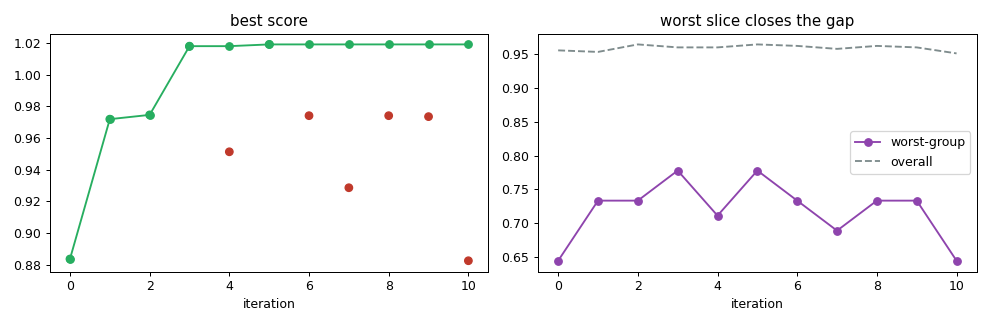

In [3]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6))
a.plot(df["iter"], df["best_so_far"], "-o", color="#27ae60"); a.set_title("best score")
a.set_xlabel("iteration")
a.scatter(df["iter"], df["score"], c=["#27ae60" if k=="True" else "#c0392b" for k in df["kept"].astype(str)], zorder=3)
b.plot(df["iter"], df["worst_group"], "-o", color="#8e44ad", label="worst-group")
b.plot(df["iter"], df["overall_accuracy"], "--", color="#7f8c8d", label="overall")
b.set_title("worst slice closes the gap"); b.set_xlabel("iteration"); b.legend()
fig.tight_layout(); fig.savefig("fig_20_case.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_20_case.png")

The product isn't a magic model — it's a **legible, bounded research process**:
every gain traced to a kept change with a rationale, every regression reverted,
the scorer provably untouched, the spend capped. Point the same contract at a new
task, dataset, or worst slice, and turn the loop.

**To run it for real:** register at bdd-data.berkeley.edu, implement the loader in
`scripts/download_bdd.py --real`, drive the loop with `ClaudeProposer` (Ch. 14) on
a Ray cluster (Ch. 9). Nothing else changes.